In [1]:
!nvidia-smi
!pip install torch torchvision matplotlib tqdm

Wed May  6 09:30:16 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   45C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [3]:
!git clone https://github.com/mashaan14/MNIST-M.git

Cloning into 'MNIST-M'...
remote: Enumerating objects: 81, done.
remote: Counting objects: 100% (81/81), done.
remote: Compressing objects: 100% (79/79), done.
remote: Total 81 (delta 47), reused 5 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (81/81), 1.58 MiB | 13.86 MiB/s, done.
Resolving deltas: 100% (47/47), done.


In [4]:
import zipfile

zip_path = "MNIST-M/MNIST-M.zip"
extract_path = "mnist_m"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

In [17]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import itertools

device = "cuda"

normalize = transforms.Normalize((0.5,), (0.5,))

# MNIST (source)
transform_mnist = transforms.Compose([
    transforms.Resize(32),
    transforms.Grayscale(3),
    transforms.ToTensor(),
    normalize
])

mnist = datasets.MNIST("./data", train=True, download=True, transform=transform_mnist)

# MNIST-M (target)
transform_mnistm = transforms.Compose([
    transforms.Resize(32),
    transforms.ToTensor(),
    normalize
])

mnist_m = datasets.ImageFolder(
    root="/content/mnist_m/MNIST-M/training",
    transform=transform_mnistm
)

mnist_m_test = datasets.ImageFolder(
    root="/content/mnist_m/MNIST-M/testing",
    transform=transform_mnistm
)

source_loader = DataLoader(mnist, batch_size=128, shuffle=True)
target_loader = DataLoader(mnist_m, batch_size=128, shuffle=True)
target_test_loader = DataLoader(mnist_m_test, batch_size=128, shuffle=False)

In [18]:
import torch.nn as nn

class GRL(torch.autograd.Function):
    @staticmethod
    def forward(ctx, x, alpha):
        ctx.alpha = alpha
        return x.view_as(x)

    @staticmethod
    def backward(ctx, grad_output):
        return grad_output.neg() * ctx.alpha, None


class FeatureExtractor(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 32, 5),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 48, 5),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

    def forward(self, x):
        return self.net(x).view(x.size(0), -1)


class LabelClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(48*5*5, 100),
            nn.ReLU(),
            nn.Linear(100, 10)
        )

    def forward(self, x):
        return self.fc(x)


class DomainClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(48*5*5, 100),
            nn.ReLU(),
            nn.Linear(100, 2)
        )

    def forward(self, x, alpha):
        x = GRL.apply(x, alpha)
        return self.fc(x)


class DANN(nn.Module):
    def __init__(self):
        super().__init__()
        self.feature = FeatureExtractor()
        self.classifier = LabelClassifier()
        self.domain = DomainClassifier()

    def forward(self, x, alpha=0):
        feat = self.feature(x)
        class_out = self.classifier(feat)
        domain_out = self.domain(feat, alpha)
        return class_out, domain_out

In [19]:
def compute_accuracy(pred, label):
    pred = pred.argmax(dim=1)
    return (pred == label).sum().item(), label.size(0)


def evaluate(model, loader):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            pred, _ = model(x, alpha=0)
            c, t = compute_accuracy(pred, y)
            correct += c
            total += t

    return correct / total

In [20]:
import torch.optim as optim
from tqdm import tqdm

model = DANN().to(device)

optimizer = optim.Adam(model.parameters(), lr=1e-4)
criterion = nn.CrossEntropyLoss()

epochs = 20
total_steps = epochs * len(source_loader)
step = 0

for epoch in range(epochs):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for (xs, ys), (xt, _) in zip(source_loader, itertools.cycle(target_loader)):
        xs, ys = xs.to(device), ys.to(device)
        xt = xt.to(device)

        # 🔥 alpha schedule chuẩn paper
        p = float(step) / total_steps
        alpha = 2. / (1. + torch.exp(torch.tensor(-10 * p))) - 1
        step += 1

        # ===== SOURCE =====
        class_out, domain_s = model(xs, alpha)
        loss_class = criterion(class_out, ys)

        c, t = compute_accuracy(class_out, ys)
        correct += c
        total += t

        domain_label_s = torch.zeros(xs.size(0)).long().to(device)
        loss_domain_s = criterion(domain_s, domain_label_s)

        # ===== TARGET =====
        _, domain_t = model(xt, alpha)
        domain_label_t = torch.ones(xt.size(0)).long().to(device)
        loss_domain_t = criterion(domain_t, domain_label_t)

        loss = loss_class + 0.1 * (loss_domain_s + loss_domain_t)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    train_acc = correct / total
    source_acc = evaluate(model, source_loader)
    target_acc = evaluate(model, target_test_loader)

    print(f"""
Epoch {epoch+1}
Loss: {total_loss:.2f}
Train Acc: {train_acc:.4f}
Source Acc: {source_acc:.4f}
Target Acc: {target_acc:.4f}
""")


Epoch 1
Loss: 280.37
Train Acc: 0.8520
Source Acc: 0.9515
Target Acc: 0.5432


Epoch 2
Loss: 91.91
Train Acc: 0.9627
Source Acc: 0.9715
Target Acc: 0.5830


Epoch 3
Loss: 72.67
Train Acc: 0.9733
Source Acc: 0.9784
Target Acc: 0.5961


Epoch 4
Loss: 56.21
Train Acc: 0.9793
Source Acc: 0.9817
Target Acc: 0.6126


Epoch 5
Loss: 49.41
Train Acc: 0.9821
Source Acc: 0.9853
Target Acc: 0.6271


Epoch 6
Loss: 44.18
Train Acc: 0.9853
Source Acc: 0.9865
Target Acc: 0.6363


Epoch 7
Loss: 41.58
Train Acc: 0.9863
Source Acc: 0.9886
Target Acc: 0.6499


Epoch 8
Loss: 37.74
Train Acc: 0.9880
Source Acc: 0.9894
Target Acc: 0.6514


Epoch 9
Loss: 34.41
Train Acc: 0.9887
Source Acc: 0.9908
Target Acc: 0.6593


Epoch 10
Loss: 31.51
Train Acc: 0.9898
Source Acc: 0.9909
Target Acc: 0.6461


Epoch 11
Loss: 29.93
Train Acc: 0.9905
Source Acc: 0.9915
Target Acc: 0.6548


Epoch 12
Loss: 28.01
Train Acc: 0.9915
Source Acc: 0.9923
Target Acc: 0.6622


Epoch 13
Loss: 26.11
Train Acc: 0.9920
Source Acc: 0.9925
T

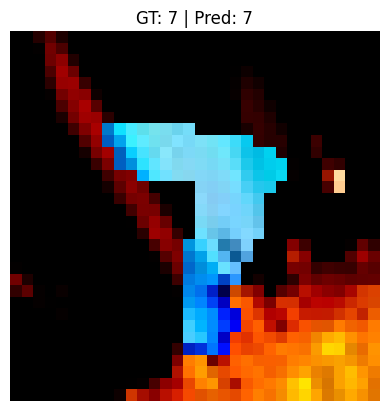

In [21]:
import random
import matplotlib.pyplot as plt

model.eval()

idx = random.randint(0, len(mnist_m_test)-1)
img, label = mnist_m_test[idx]

with torch.no_grad():
    pred, _ = model(img.unsqueeze(0).to(device))
    pred = pred.argmax(1).item()

plt.imshow(img.permute(1,2,0))
plt.title(f"GT: {label} | Pred: {pred}")
plt.axis("off")
plt.show()

In [22]:
import torch.nn as nn
import torchvision.models as models

class DANN_ResNet(nn.Module):
    def __init__(self):
        super().__init__()

        resnet = models.resnet18(pretrained=True)
        self.feature = nn.Sequential(*list(resnet.children())[:-1])  # bỏ FC

        self.classifier = nn.Sequential(
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, 10)
        )

        self.domain = nn.Sequential(
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, 2)
        )

    def forward(self, x, alpha=0):
        feat = self.feature(x)
        feat = feat.view(feat.size(0), -1)

        class_out = self.classifier(feat)

        reverse_feat = GRL.apply(feat, alpha)
        domain_out = self.domain(reverse_feat)

        return class_out, domain_out

In [23]:
import torch.optim as optim
from tqdm import tqdm
import itertools

model = DANN_ResNet().to(device)

optimizer = optim.Adam(model.parameters(), lr=1e-4)
criterion = nn.CrossEntropyLoss()

#  LR scheduler
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

epochs = 40
total_steps = epochs * len(source_loader)
step = 0

for epoch in range(epochs):
    model.train()

    total_loss = 0
    correct = 0
    total = 0

    for (xs, ys), (xt, _) in zip(source_loader, itertools.cycle(target_loader)):
        xs, ys = xs.to(device), ys.to(device)
        xt = xt.to(device)

        #  alpha schedule (paper)
        p = float(step) / total_steps
        alpha = 2. / (1. + torch.exp(torch.tensor(-10 * p))) - 1

        #  domain weight schedule
        lambda_d = min(1.0, step / total_steps)

        step += 1

        # ===== SOURCE =====
        class_out, domain_s = model(xs, alpha)
        loss_class = criterion(class_out, ys)

        c, t = compute_accuracy(class_out, ys)
        correct += c
        total += t

        domain_label_s = torch.zeros(xs.size(0)).long().to(device)
        loss_domain_s = criterion(domain_s, domain_label_s)

        # ===== TARGET =====
        _, domain_t = model(xt, alpha)
        domain_label_t = torch.ones(xt.size(0)).long().to(device)
        loss_domain_t = criterion(domain_t, domain_label_t)

        #  WARMUP (rất quan trọng)
        if epoch < 3:
            loss = loss_class
        else:
            loss = loss_class + lambda_d * 0.1 * (loss_domain_s + loss_domain_t)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    scheduler.step()

    train_acc = correct / total
    source_acc = evaluate(model, source_loader)
    target_acc = evaluate(model, target_test_loader)

    print(f"""
 Epoch {epoch+1}
Loss: {total_loss:.2f}
Train Acc: {train_acc:.4f}
Source Acc: {source_acc:.4f}
Target Acc: {target_acc:.4f}
LR: {scheduler.get_last_lr()[0]:.6f}
""")

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 181MB/s]



 Epoch 1
Loss: 80.89
Train Acc: 0.9557
Source Acc: 0.9807
Target Acc: 0.4914
LR: 0.000100


 Epoch 2
Loss: 14.51
Train Acc: 0.9907
Source Acc: 0.9837
Target Acc: 0.5272
LR: 0.000100


 Epoch 3
Loss: 9.82
Train Acc: 0.9936
Source Acc: 0.9926
Target Acc: 0.5190
LR: 0.000100


 Epoch 4
Loss: 10.78
Train Acc: 0.9951
Source Acc: 0.9850
Target Acc: 0.5637
LR: 0.000100


 Epoch 5
Loss: 10.97
Train Acc: 0.9957
Source Acc: 0.9929
Target Acc: 0.5884
LR: 0.000100


 Epoch 6
Loss: 11.83
Train Acc: 0.9964
Source Acc: 0.9943
Target Acc: 0.6026
LR: 0.000100


 Epoch 7
Loss: 13.74
Train Acc: 0.9963
Source Acc: 0.9949
Target Acc: 0.6288
LR: 0.000100


 Epoch 8
Loss: 15.96
Train Acc: 0.9969
Source Acc: 0.9967
Target Acc: 0.6538
LR: 0.000100


 Epoch 9
Loss: 19.34
Train Acc: 0.9970
Source Acc: 0.9972
Target Acc: 0.6686
LR: 0.000100


 Epoch 10
Loss: 21.07
Train Acc: 0.9969
Source Acc: 0.9969
Target Acc: 0.6626
LR: 0.000050


 Epoch 11
Loss: 19.99
Train Acc: 0.9984
Source Acc: 0.9980
Target Acc: 0.6692
L

In [27]:
import random
import matplotlib.pyplot as plt

def test_random_images(model, dataset, device, num_samples=5):
    model.eval()

    indices = random.sample(range(len(dataset)), num_samples)

    plt.figure(figsize=(12, 3))

    for i, idx in enumerate(indices):
        img, label = dataset[idx]

        with torch.no_grad():
            pred, _ = model(img.unsqueeze(0).to(device), alpha=0)
            pred = pred.argmax(1).item()

        img_show = img.permute(1, 2, 0).cpu().numpy()

        plt.subplot(1, num_samples, i+1)
        plt.imshow(img_show)
        plt.title(f"GT: {label}\nPred: {pred}",
                  color=("green" if pred == label else "red"))
        plt.axis("off")

    plt.tight_layout()
    plt.show()

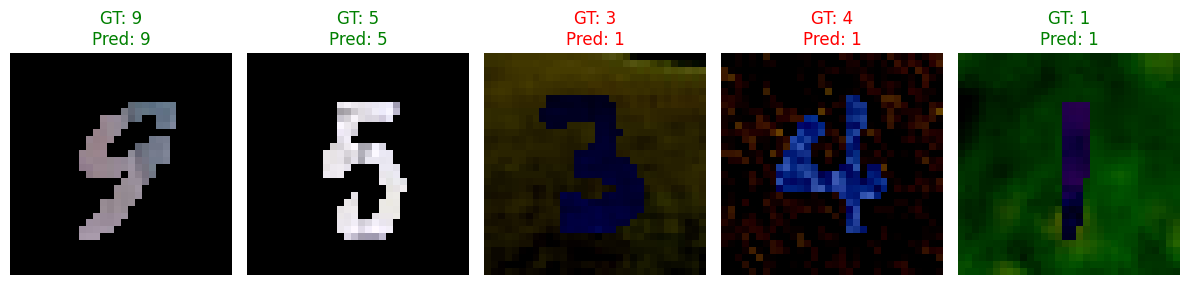

In [28]:
test_random_images(model, mnist_m_test, device, num_samples=5)

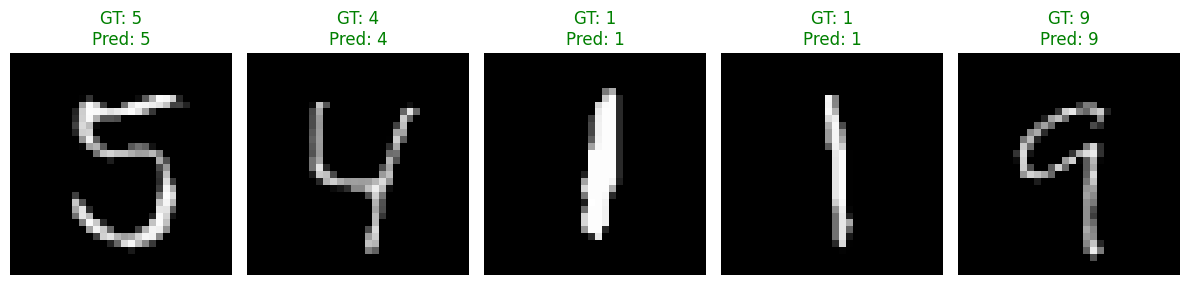

In [29]:
test_random_images(model, mnist, device, num_samples=5)

In [30]:
import torch.nn.functional as F

def test_random_images_with_conf(model, dataset, device, num_samples=5):
    model.eval()

    indices = random.sample(range(len(dataset)), num_samples)

    plt.figure(figsize=(12, 3))

    for i, idx in enumerate(indices):
        img, label = dataset[idx]

        with torch.no_grad():
            logits, _ = model(img.unsqueeze(0).to(device), alpha=0)
            probs = F.softmax(logits, dim=1)
            pred = probs.argmax(1).item()
            conf = probs.max().item()

        img_show = img.permute(1, 2, 0).cpu().numpy()

        plt.subplot(1, num_samples, i+1)
        plt.imshow(img_show)
        plt.title(f"GT:{label} | P:{pred}\nConf:{conf:.2f}",
                  color=("green" if pred == label else "red"))
        plt.axis("off")

    plt.tight_layout()
    plt.show()

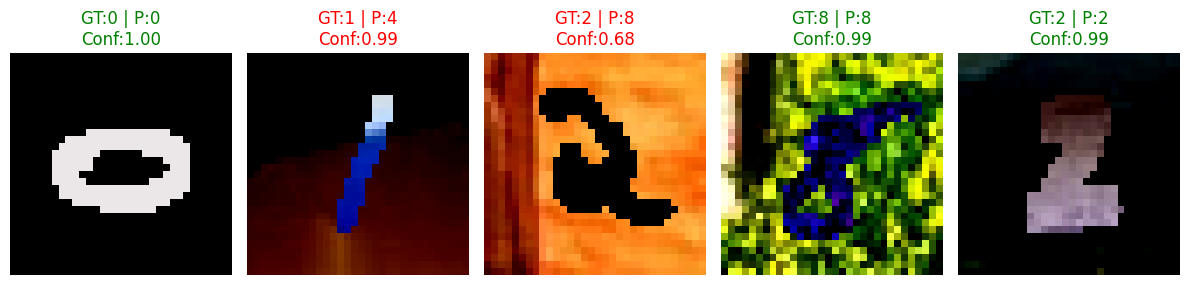

In [31]:
test_random_images_with_conf(model, mnist_m_test, device, num_samples=5)

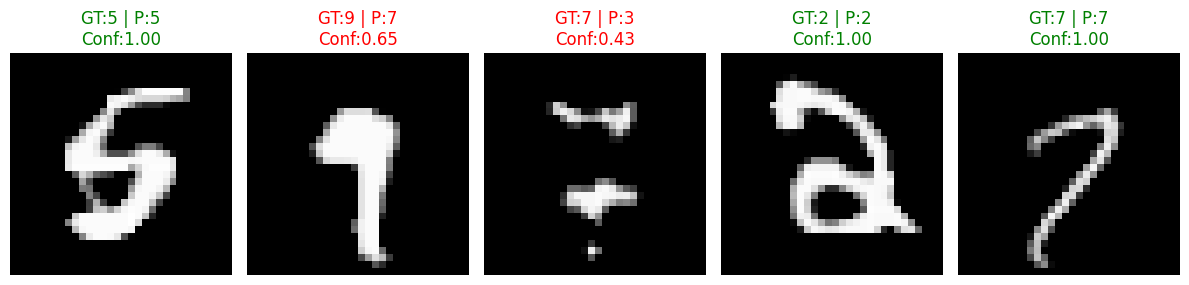

In [32]:
test_random_images_with_conf(model, mnist, device, num_samples=5)

=== SOURCE ===


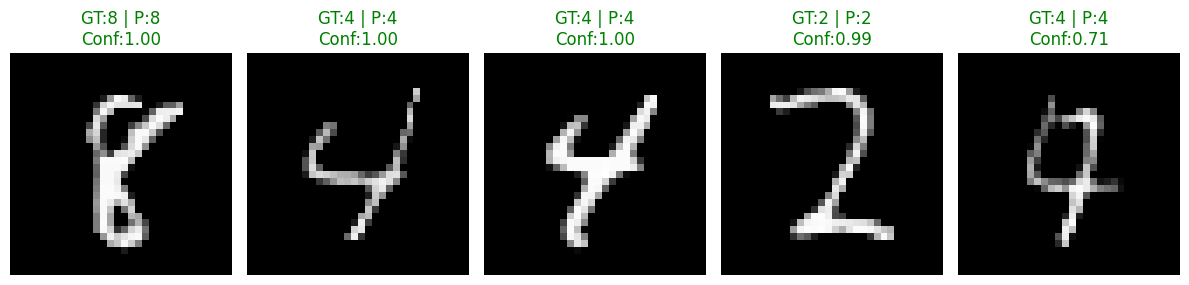

=== TARGET ===


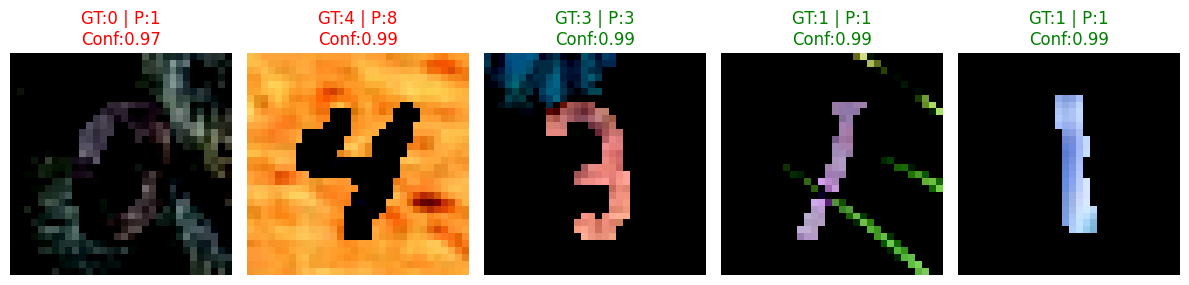

In [33]:
print("=== SOURCE ===")
test_random_images_with_conf(model, mnist, device)

print("=== TARGET ===")
test_random_images_with_conf(model, mnist_m_test, device)